In [1]:
%pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**LIBRARIES**

In [2]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

**R0**

Columnas detectadas: ['RUN', 'X', 'Y']
------------------------------
Resultados guardados en: ./Himmelblau_R0_RESULTADO.csv
------------------------------
   RUN     X        Y          R0
0    1  1.02  0.60000  119.186512
1    2  1.08  6.00000  919.502889
2    3 -3.00  1.86000   42.796432
3    4 -6.00 -1.20000  700.073600
4    5 -6.00 -5.23437  598.000655


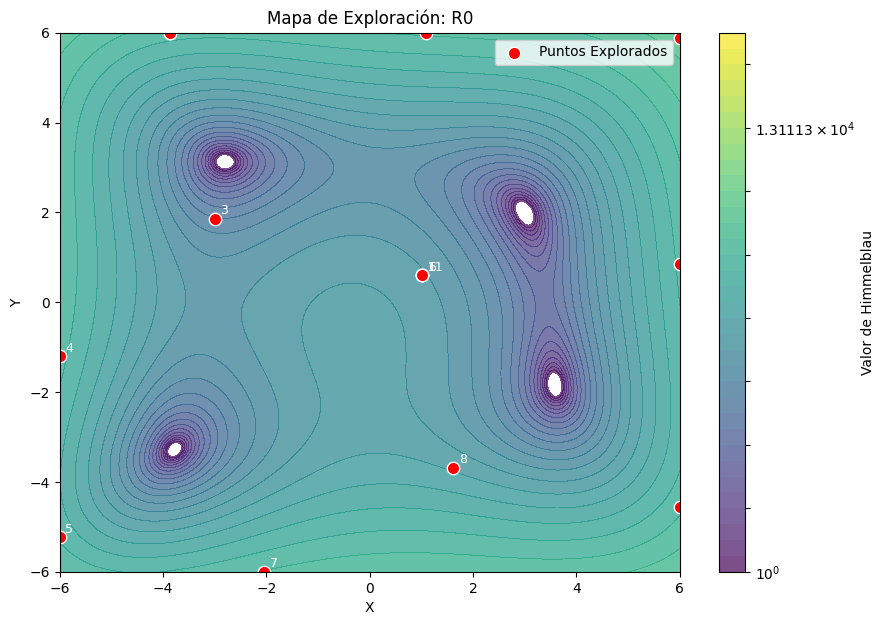

Gráfico guardado correctamente com :./Himmelblau_R0_plot.jpg


In [3]:
# Definimos la ruta de entrada
input_file = "./Himmelblau_R0.csv"

# Definimos la ruta de salida (en la misma carpeta)
output_file = "./Himmelblau_R0_RESULTADO.csv"
output_plot = "./Himmelblau_R0_plot.jpg"

   
try:

    # 1. Cargar datos 
    # Leemos el archivo detectando automáticamente el separador (puede ser coma, punto y coma, tabulación, etc.)
    df = pd.read_csv(input_file, sep=None, engine='python')

    # Limpiamos nombres de columnas (quita espacios invisibles como " X" -> "X")
    df.columns = df.columns.str.strip()
    print(f"Columnas detectadas: {list(df.columns)}")


    # 2. Definir la función de Himmelblau
    def himmelblau(x, y):
        return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

    # 3. Extraer valores de la columna 2 (X) y de la columna 3(Y) (Usando .iloc es más seguro si las columnas son la 2 y la 3)
    val_x = df.iloc[:, 1] # iloc[:, 1] es la segunda columna donde estan los valores de X
    val_y = df.iloc[:, 2] # iloc[:, 2] es la tercera columna donde estan los valores de Y

    # 4. Calcular el resultado y guardarlo en la nueva columna 4 (indice 3)
    df['R0'] = himmelblau(val_x, val_y)

    # 5. Guardar el archivo actualizado en el Escritorio
    df.to_csv(output_file, index=False)

    print("-" * 30)
    print(f"Resultados guardados en: {output_file}")
    print("-" * 30)
    print(df.head()) # Mostrar los primeros resultados para verificar



###-PLOT-###
    # 1. Crear el fondo de la función
    x_range = np.linspace(-6, 6, 400)
    y_range = np.linspace(-6, 6, 400)
    X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
    Z_mesh = himmelblau(X_mesh, Y_mesh)

    # 2. Dibujar el mapa
    plt.figure(figsize=(10, 7))
    plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(0, 5, 35), norm=LogNorm(), cmap='viridis', alpha=0.7)
    plt.colorbar(label='Valor de Himmelblau')

    # 3. Dibujar TUS puntos (usando el df que ya tienes en memoria)
    plt.scatter(df.iloc[:, 1], df.iloc[:, 2], color='red', edgecolors='white', s=80, label='Puntos Explorados')

    # Añadir etiquetas de número de RUN
    for i, row in df.iterrows():
        plt.text(row.iloc[1]+0.1, row.iloc[2]+0.1, str(int(row.iloc[0])), color='white', fontsize=9)

    plt.title("Mapa de Exploración: R0")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()

    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Gráfico guardado correctamente com :{output_plot}")

#except FileNotFoundError:
#   print(f"Error: No se encontró el archivo en {input_file}")
except Exception as e: 
    print(f"Ocurrió un error: {e}")


**R1**

In [ ]:
# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Himmelblau\Himmelblau_R1.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def himmelblau(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

minimos = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = himmelblau(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias a los 4 mínimos
for i, (mx, my) in enumerate(minimos, 1):
    df[f'M{i}'] = np.sqrt((x - mx)**2 + (y - my)**2)

# 4. FILA DE RESUMEN (Final del archivo)
resumen = pd.Series({'Number': 'RESUMEN', 'Real': df['Real'].min(), 'MAE': df['MAE'].mean()})
for i in range(1, 5): resumen[f'M{i}'] = df[f'M{i}'].min()
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

print(resumen)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-6, 6, 400)
y_range = np.linspace(-6, 6, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = (X_mesh**2 + Y_mesh - 11)**2 + (X_mesh + Y_mesh**2 - 7)**2

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(0, 5, 35), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Himmelblau')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(df.iloc[:, 1], df.iloc[:, 2], color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R1 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado correctamente com :{plot_path}")



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Usuario\\Desktop\\Himmelblau\\Himmelblau_R1.csv'

**R2**

Number     RESUMEN
Real       2.94174
MAE       0.004409
M1        0.650692
M2        0.377975
M3        0.281853
M4        0.342405
dtype: object


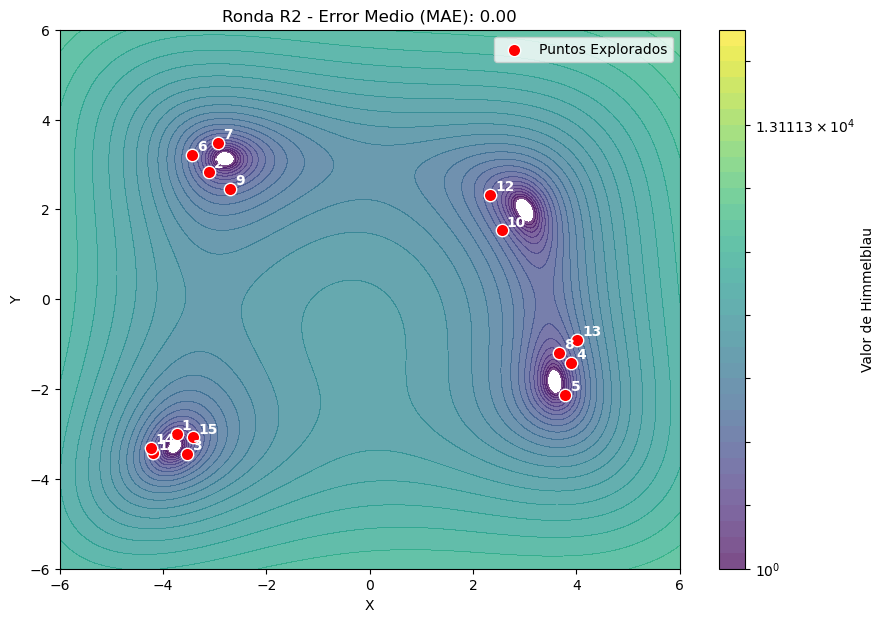

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Himmelblau\Himmelblau_R2_Grafico.jpg


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Himmelblau\Himmelblau_R2.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def himmelblau(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

minimos = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = himmelblau(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias a los 4 mínimos
for i, (mx, my) in enumerate(minimos, 1):
    df[f'M{i}'] = np.sqrt((x - mx)**2 + (y - my)**2)

# 4. FILA DE RESUMEN (Final del archivo)
resumen = pd.Series({'Number': 'RESUMEN', 'Real': df['Real'].min(), 'MAE': df['MAE'].mean()})
for i in range(1, 5): resumen[f'M{i}'] = df[f'M{i}'].min()
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

print(resumen) 

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-6, 6, 400)
y_range = np.linspace(-6, 6, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = (X_mesh**2 + Y_mesh - 11)**2 + (X_mesh + Y_mesh**2 - 7)**2

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(0, 5, 35), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Himmelblau')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(df.iloc[:, 1], df.iloc[:, 2], color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R2 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado correctamente com :{plot_path}")



**R3**

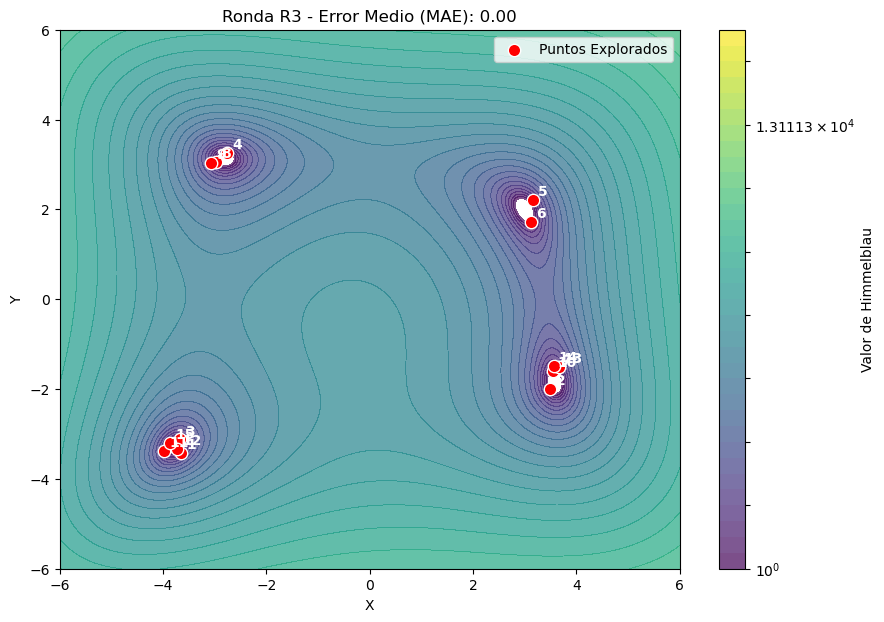

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Himmelblau\Himmelblau_R3_Grafico.jpg


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Himmelblau\Himmelblau_R3.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def himmelblau(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

minimos = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = himmelblau(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias a los 4 mínimos
for i, (mx, my) in enumerate(minimos, 1):
    df[f'M{i}'] = np.sqrt((x - mx)**2 + (y - my)**2)

# 4. FILA DE RESUMEN (Final del archivo)
resumen = pd.Series({'Number': 'RESUMEN', 'Real': df['Real'].min(), 'MAE': df['MAE'].mean()})
for i in range(1, 5): resumen[f'M{i}'] = df[f'M{i}'].min()
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-6, 6, 400)
y_range = np.linspace(-6, 6, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = (X_mesh**2 + Y_mesh - 11)**2 + (X_mesh + Y_mesh**2 - 7)**2

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(0, 5, 35), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Himmelblau')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(df.iloc[:, 1], df.iloc[:, 2], color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass

plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R3 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()


print(f"Gráfico guardado correctamente com :{plot_path}")

**R4**

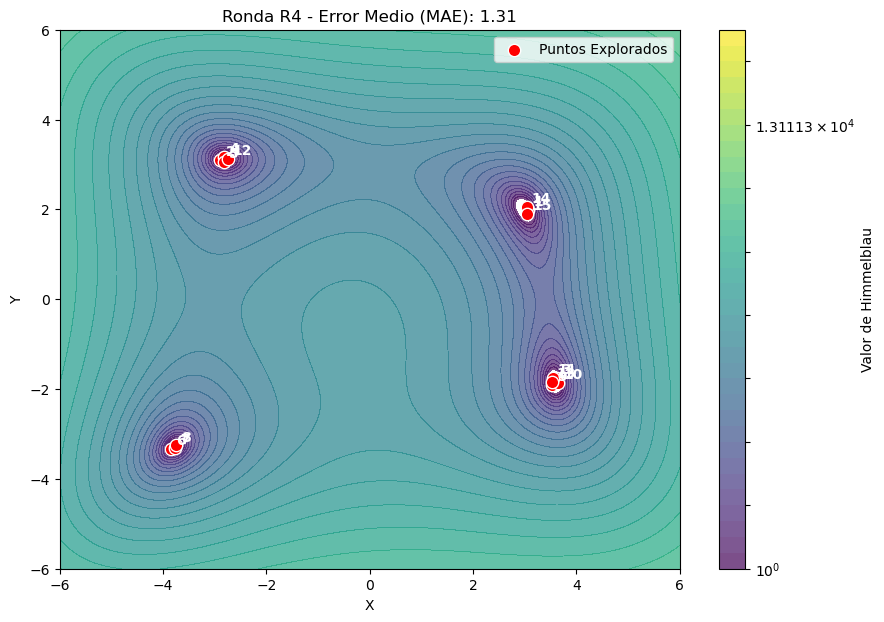

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Himmelblau\Himmelblau_R4_Grafico.jpg


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Himmelblau\Himmelblau_R4.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def himmelblau(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

minimos = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = himmelblau(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias a los 4 mínimos
for i, (mx, my) in enumerate(minimos, 1):
    df[f'M{i}'] = np.sqrt((x - mx)**2 + (y - my)**2)

# 4. FILA DE RESUMEN (Final del archivo)
resumen = pd.Series({'Number': 'RESUMEN', 'Real': df['Real'].min(), 'MAE': df['MAE'].mean()})
for i in range(1, 5): resumen[f'M{i}'] = df[f'M{i}'].min()
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-6, 6, 400)
y_range = np.linspace(-6, 6, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = (X_mesh**2 + Y_mesh - 11)**2 + (X_mesh + Y_mesh**2 - 7)**2

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(0, 5, 35), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Himmelblau')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(df.iloc[:, 1], df.iloc[:, 2], color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass

plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R4 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()


print(f"Gráfico guardado correctamente com :{plot_path}")

**R5**

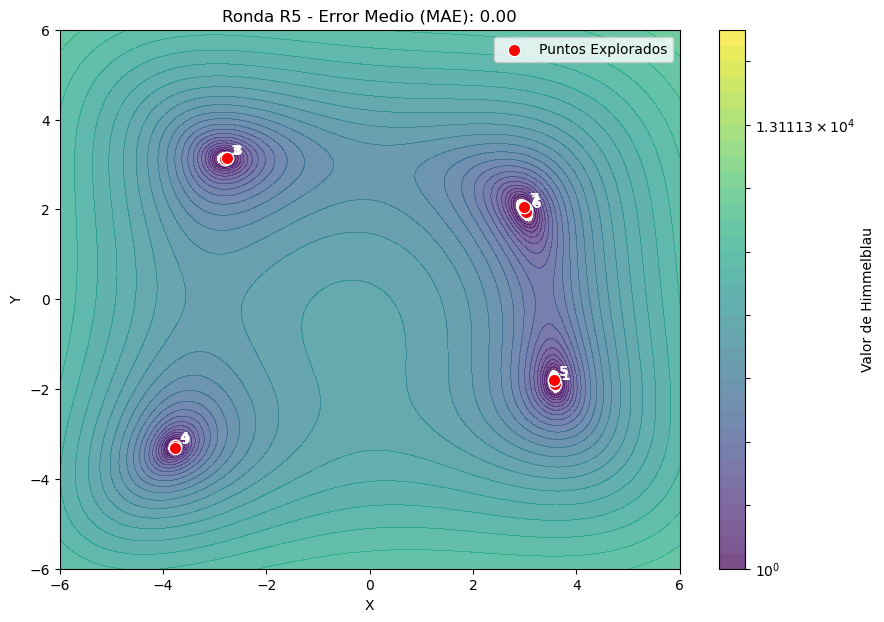

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Himmelblau\Himmelblau_R5_Grafico.jpg


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Himmelblau\Himmelblau_R5.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def himmelblau(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

minimos = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = himmelblau(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias a los 4 mínimos
for i, (mx, my) in enumerate(minimos, 1):
    df[f'M{i}'] = np.sqrt((x - mx)**2 + (y - my)**2)

# 4. FILA DE RESUMEN (Final del archivo)
resumen = pd.Series({'Number': 'RESUMEN', 'Real': df['Real'].min(), 'MAE': df['MAE'].mean()})
for i in range(1, 5): resumen[f'M{i}'] = df[f'M{i}'].min()
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-6, 6, 400)
y_range = np.linspace(-6, 6, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = (X_mesh**2 + Y_mesh - 11)**2 + (X_mesh + Y_mesh**2 - 7)**2

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(0, 5, 35), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Himmelblau')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(df.iloc[:, 1], df.iloc[:, 2], color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass

plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R5 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado correctamente com :{plot_path}")

**R6**

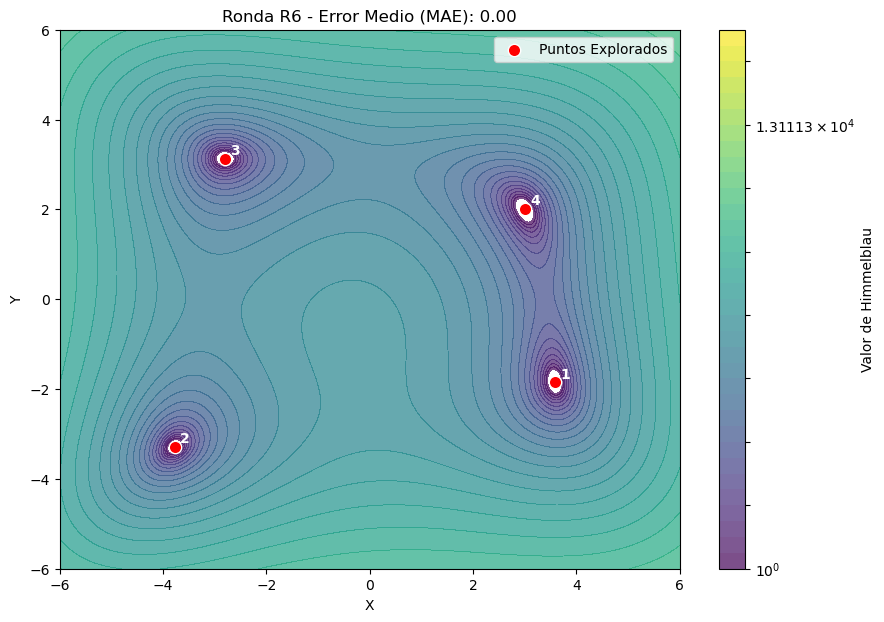

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Himmelblau\Himmelblau_R6_Grafico.jpg


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Himmelblau\Himmelblau_R6.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def himmelblau(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

minimos = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = himmelblau(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias a los 4 mínimos
for i, (mx, my) in enumerate(minimos, 1):
    df[f'M{i}'] = np.sqrt((x - mx)**2 + (y - my)**2)

# 4. FILA DE RESUMEN (Final del archivo)
resumen = pd.Series({'Number': 'RESUMEN', 'Real': df['Real'].min(), 'MAE': df['MAE'].mean()})
for i in range(1, 5): resumen[f'M{i}'] = df[f'M{i}'].min()
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-6, 6, 400)
y_range = np.linspace(-6, 6, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = (X_mesh**2 + Y_mesh - 11)**2 + (X_mesh + Y_mesh**2 - 7)**2

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(0, 5, 35), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Himmelblau')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(df.iloc[:, 1], df.iloc[:, 2], color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass


plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R6 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado correctamente com :{plot_path}")


**TAULA RESUM**

In [10]:
import pandas as pd
import os

# 1. CONFIGURACIÓ
folder_path = r"C:\Users\Usuario\Desktop\Himmelblau"
rondes = [1, 2, 3, 4, 5, 6] # Ajusta segons els teus fitxers (R1 a R6 segons la teva imatge)
resum_dades = []

# 2. BUCLE DE PROCESSAMENT
for r in rondes:
    # Ajusta el nom del fitxer si porten el prefix "_act"
    file_name = f"Himmelblau_R{r}_RESULTADO.csv" 
    file_path = os.path.join(folder_path, file_name)
    
    if os.path.exists(file_path):
        try:
            # Llegim el CSV
            df = pd.read_csv(file_path, sep=',', engine='python')
            df.columns = df.columns.str.strip()
            
            # Busquem la fila on la primera columna (Number) diu "RESUMEN"
            fila_resum = df[df.iloc[:, 0] == 'RESUMEN']
            
            if not fila_resum.empty:
                # Extraiem els valors directament de la fila RESUMEN
                resum_dades.append({
                    'RONDES': r,
                    'Distància M1': round(float(fila_resum['M1'].values[0]), 2),
                    'Distància M2': round(float(fila_resum['M2'].values[0]), 2),
                    'Distància M3': round(float(fila_resum['M3'].values[0]), 2),
                    'Distància M4': round(float(fila_resum['M4'].values[0]), 2),
                    'MAE': round(float(fila_resum['MAE'].values[0]), 2),
                    'FUNC': round(float(fila_resum['Real'].values[0]), 2)
                })
            else:
                print(f"Avís: No s'ha trobat la fila RESUMEN a R{r}")
                
        except Exception as e:
            print(f"Error processant R{r}: {e}")
    else:
        print(f"Fitxer no trobat: {file_path}")

# 3. CREAR LA TAULA FINAL
if resum_dades:
    df_final = pd.DataFrame(resum_dades)
    
    # Ordenar les rondes per si de cas
    df_final = df_final.sort_values('RONDES')

    print("\n--- TAULA RESUM HIMMELBLAU (Valors de RESUMEN) ---")
    print(df_final.to_string(index=False))

    # 4. GUARDAR
    output_file = os.path.join(folder_path, "Resum_Himmelblau_Final.csv")
    df_final.to_csv(output_file, index=False)
    print(f"\nTaula guardada a: {output_file}")
else:
    print("No s'han pogut recollir dades.")

Error processant R1: 'M1'

--- TAULA RESUM HIMMELBLAU (Valors de RESUMEN) ---
 RONDES  Distància M1  Distància M2  Distància M3  Distància M4     MAE    FUNC
      2          0.65          0.38          0.28          0.34     0.0    2.94
      3          0.27          0.14          0.07          0.17     0.0    0.31
      4          0.06          0.04          0.03          0.06 15000.2 1972.12
      5          0.02          0.01          0.02          0.03     0.0    0.00
      6          0.00          0.00          0.00          0.00     0.0    0.00

Taula guardada a: C:\Users\Usuario\Desktop\Himmelblau\Resum_Himmelblau_Final.csv


In [15]:
import pandas as pd
import os

# 1. CONFIGURACIÓ
folder_path = r"C:\Users\Usuario\Desktop\Himmelblau"
# Llista de les rondes que vols incloure (ex: R1 a R6)
rondes = [1, 2, 3, 4, 5, 6] 
resum_final = []

for r in rondes:
    # Anem a buscar el fitxer que ja té la fila RESUMEN
    file_name = f"Himmelblau_R{r}_RESULTADO.csv"
    file_path = os.path.join(folder_path, file_name)
    
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            # Busquem la fila on la columna 'Number' és 'RESUMEN'
            fila_resum = df[df['Number'] == 'RESUMEN']
            
            if not fila_resum.empty:
                resum_final.append({
                    'RONDES': r,
                    'Distància M1': round(float(fila_resum['M1'].values[0]), 2),
                    'Distància M2': round(float(fila_resum['M2'].values[0]), 2),
                    'Distància M3': round(float(fila_resum['M3'].values[0]), 2),
                    'Distància M4': round(float(fila_resum['M4'].values[0]), 2),
                    'MAE': round(float(fila_resum['MAE'].values[0]), 2),
                    'FUNC': round(float(fila_resum['Real'].values[0]), 2)
                })
        except Exception as e:
            print(f"Error en llegir la Ronda {r}: {e}")

# 2. CREAR EL DATAFRAME FINAL
df_comparatiu = pd.DataFrame(resum_final)

# 3. MOSTRAR I GUARDAR
print("\n--- TAULA RESUM DE TOTS ELS MÍNIMS PER RONDA ---")
print(df_comparatiu.to_string(index=False))

output_path = os.path.join(folder_path, "Taula_Comparativa_Himmelblau.csv")
df_comparatiu.to_csv(output_path, index=False)
print(f"\nTaula guardada a: {output_path}")

Error en llegir la Ronda 1: 'M1'

--- TAULA RESUM DE TOTS ELS MÍNIMS PER RONDA ---
 RONDES  Distància M1  Distància M2  Distància M3  Distància M4     MAE    FUNC
      2          0.65          0.38          0.28          0.34     0.0    2.94
      3          0.27          0.14          0.07          0.17     0.0    0.31
      4          0.06          0.04          0.03          0.06 15000.2 1972.12
      5          0.02          0.01          0.02          0.03     0.0    0.00
      6          0.00          0.00          0.00          0.00     0.0    0.00

Taula guardada a: C:\Users\Usuario\Desktop\Himmelblau\Taula_Comparativa_Himmelblau.csv


In [31]:
import pandas as pd
import os

# 1. CONFIGURACIÓ
folder_path = r"C:\Users\Usuario\Desktop\Himmelblau"
# Llista de les rondes que vols incloure (R1, R2, R3...)
rondes = [1, 2, 3, 4, 5, 6] 
resum_final = []

# 2. BUCLE PER LLEGIR CADA ARXIU _RESULTADO
for r in rondes:
    file_name = f"Himmelblau_R{r}_RESULTADO.csv"
    file_path = os.path.join(folder_path, file_name)
    
    if os.path.exists(file_path):
        try:
            # Llegim el fitxer. sep=',' perquè el teu fitxer generat ja és CSV estàndard
            df = pd.read_csv(file_path, sep=',', engine='python')
            df.columns = df.columns.str.strip()
            
            # Busquem la fila on la columna 'Number' és exactament 'RESUMEN'
            # Això ignora automàticament totes les files amb ,,,,,,,, que es veuen a la imatge
            fila_resum = df[df['Number'] == 'RESUMEN']
            
            if not fila_resum.empty:
                # Extraiem les dades usant els noms exactes de les teves columnes
                resum_final.append({
                    'RONDES': f'R{r}',
                    'Distància M1': round(float(fila_resum['M1'].values[0]), 3),
                    'Distància M2': round(float(fila_resum['M2'].values[0]), 3),
                    'Distància M3': round(float(fila_resum['M3'].values[0]), 3),
                    'Distància M4': round(float(fila_resum['M4'].values[0]), 3),
                    'MAE': round(float(fila_resum['MAE'].values[0]), 3),
                    'FUNC': round(float(fila_resum['Real'].values[0]), 3)
                })
            else:
                print(f"Avís: No s'ha trobat la fila RESUMEN a la Ronda {r}")
                
        except Exception as e:
            print(f"Error processant la Ronda {r}: {e}")
    else:
        print(f"No s'ha trobat el fitxer: {file_name}")

# 3. CREAR EL DATAFRAME DE LA TAULA COMPARATIVA
if resum_final:
    df_taula_resum = pd.DataFrame(resum_final)
    
    # 4. MOSTRAR I GUARDAR
    print("\n--- TAULA RESUM CONSOLIDADA (TOTES LES RONDES) ---")
    print(df_taula_resum.to_string(index=False))
    
    output_consolidat = os.path.join(folder_path, "Taula_Resum_Global_Himmelblau.csv")
    df_taula_resum.to_csv(output_consolidat, index=False)
    print(f"\nTaula consolidada guardada correctament a:\n{output_consolidat}")
else:
    print("No s'han trobat dades de resum per processar.")


--- TAULA RESUM CONSOLIDADA (TOTES LES RONDES) ---
RONDES  Distància M1  Distància M2  Distància M3  Distància M4       MAE     FUNC
    R1         2.892         1.769         0.625         1.940   679.752   23.619
    R2         0.651         0.378         0.282         0.342     0.004    2.942
    R3         0.271         0.140         0.069         0.166     0.005    0.313
    R4         0.061         0.039         0.032         0.064 15000.205 1972.118
    R5         0.019         0.006         0.017         0.032     0.001    0.001
    R6         0.002         0.004         0.003         0.004     0.000    0.000

Taula consolidada guardada correctament a:
C:\Users\Usuario\Desktop\Himmelblau\Taula_Resum_Global_Himmelblau.csv


Gràfic de Sampling guardat a: C:\Users\Usuario\Desktop\Himmelblau\Grafic_Sampling_Consolidat.jpg


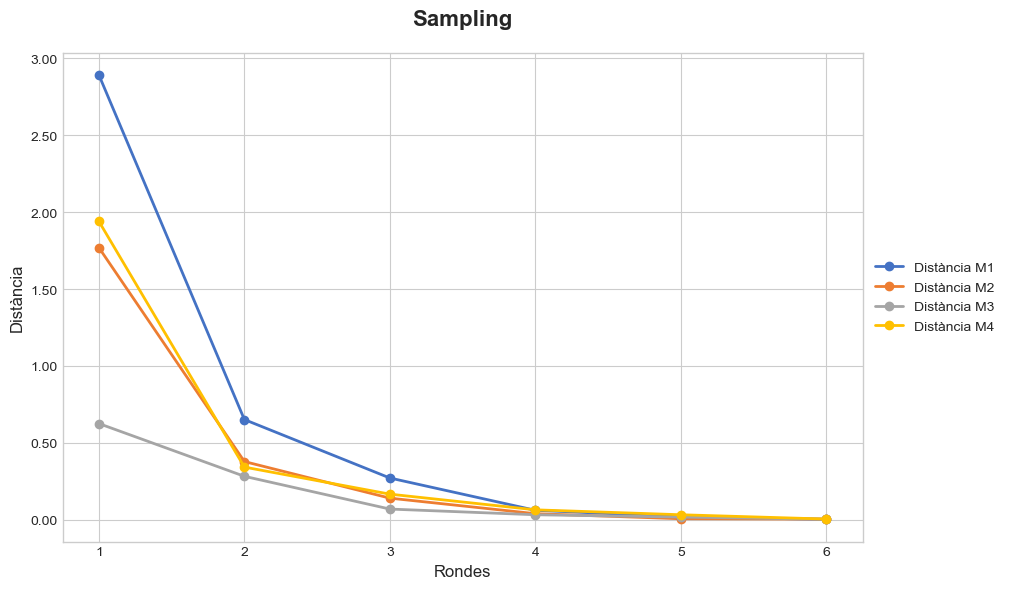

Gràfic de Fitting guardat a: C:\Users\Usuario\Desktop\Himmelblau\Grafic_Fitting_Consolidat.jpg


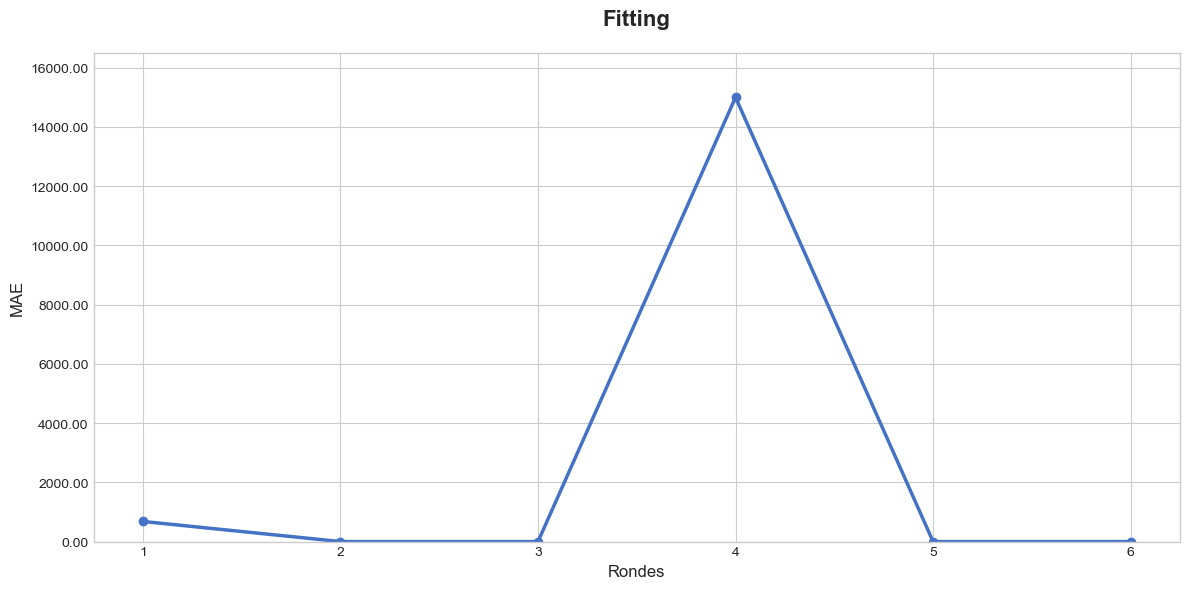

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- PART 1: SUPOSANT QUE JA TENS LA TAULA CONSOLIDADA ---
# (Si no la tens en memòria, la carreguem del fitxer que hem guardat abans)
folder_path = r"C:\Users\Usuario\Desktop\Himmelblau"
input_consolidat = os.path.join(folder_path, "Taula_Resum_Global_Himmelblau.csv")

if os.path.exists(input_consolidat):
    # Carreguem les dades. Assegura't que 'RONDES' sigui tractada com a text per a l'eix X
    df = pd.read_csv(input_consolidat)
    
    # Extraiem el número de ronda per a l'eix X (per tenir 1, 2, 3... en lloc de R1, R2, R3...)
    # Això assumeix que 'RONDES' té format 'R1', 'R2', etc.
    df['Num_Ronda'] = df['RONDES'].str.replace('R', '').astype(int)
    
    # Ordenem per ronda per si de cas
    df = df.sort_values('Num_Ronda')

    # Configurar el format del gràfic
    plt.style.use('seaborn-v0_8-whitegrid') # Un estil net similar a l'Excel

    # =========================================================
    # --- GRÀFIC 1: SAMPLING (Distàncies M1-M4) ---
    # =========================================================
    plt.figure(figsize=(12, 6))
    
    # Definir colors per coincidir amb la teva imatge d'exemple
    colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000'] # Blau, Taronja, Gris, Groc
    columnes_dist = ['Distància M1', 'Distància M2', 'Distància M3', 'Distància M4']
    labels_dist = ['Distància M1', 'Distància M2', 'Distància M3', 'Distància M4']

    for i, columna in enumerate(columnes_dist):
        plt.plot(df['Num_Ronda'], df[columna], 
                 marker='o', linestyle='-', color=colors[i], 
                 label=labels_dist[i], linewidth=2)

    # Configuració d'eixos i títols
    plt.title('Sampling', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Rondes', fontsize=12)
    plt.ylabel('Distància', fontsize=12)
    
    # Forçar l'eix X per mostrar només els números enters de les rondes (1, 2, 3...)
    plt.xticks(df['Num_Ronda'])
    
    # Configurar l'eix Y per tenir el format adequat (ex: 3.50, 3.00...)
    ax1 = plt.gca()
    ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    
    # Llegenda a la dreta
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
    
    # Ajustar per no tallar la llegenda
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    
    # Guardar i mostrar el primer gràfic
    plot_path_sampling = os.path.join(folder_path, "Grafic_Sampling_Consolidat.jpg")
    plt.savefig(plot_path_sampling, dpi=300)
    print(f"Gràfic de Sampling guardat a: {plot_path_sampling}")
    plt.show()

    # =========================================================
    # --- GRÀFIC 2: FITTING (MAE) ---
    # =========================================================
    plt.figure(figsize=(12, 6))
    
    # Dibuixar la línia del MAE ( Blau fosc similar al teu exemple )
    color_mae = '#4472C4'
    plt.plot(df['Num_Ronda'], df['MAE'], 
             marker='o', linestyle='-', color=color_mae, 
             label='Error Medio (MAE)', linewidth=2.5)

    # Configuració d'eixos i títols
    plt.title('Fitting', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Rondes', fontsize=12)
    plt.ylabel('MAE', fontsize=12)
    
    # Forçar l'eix X per mostrar els números de ronda (1, 2, 3...)
    plt.xticks(df['Num_Ronda'])
    
    # Configurar l'eix Y (ex: 800.00, 700.00...)
    ax2 = plt.gca()
    ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    # Deixar una mica d'espai a dalt
    if not df['MAE'].empty:
        plt.ylim(0, df['MAE'].max() * 1.1) 
    
    # No cal llegenda si només hi ha una línia, però l'afegim per consistència
    # plt.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    
    # Guardar i mostrar el segon gràfic
    plot_path_fitting = os.path.join(folder_path, "Grafic_Fitting_Consolidat.jpg")
    plt.savefig(plot_path_fitting, dpi=300)
    print(f"Gràfic de Fitting guardat a: {plot_path_fitting}")
    plt.show()

else:
    print(f"Error: No s'ha trobat el fitxer consolidat a: {input_consolidat}")

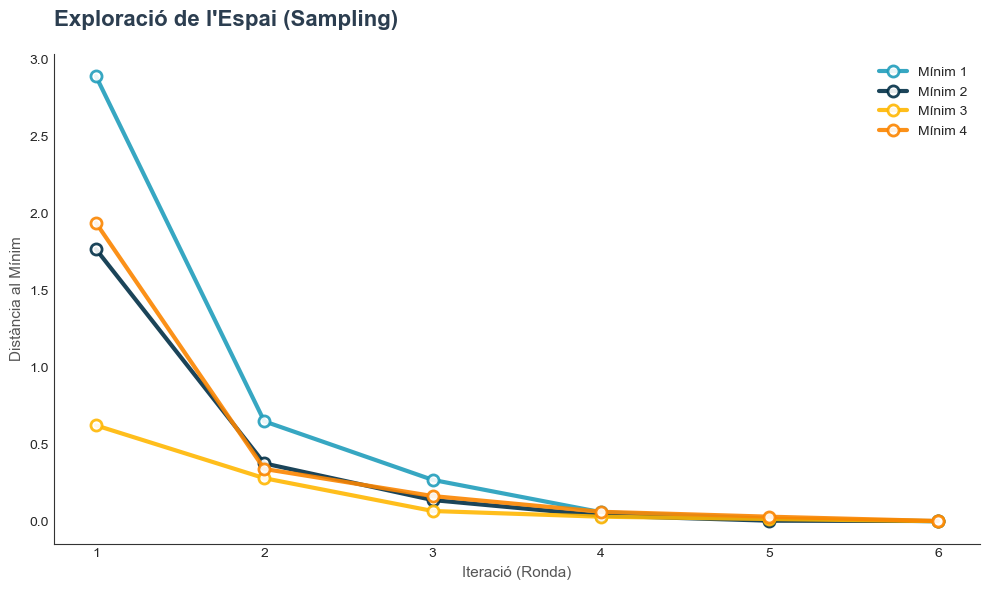

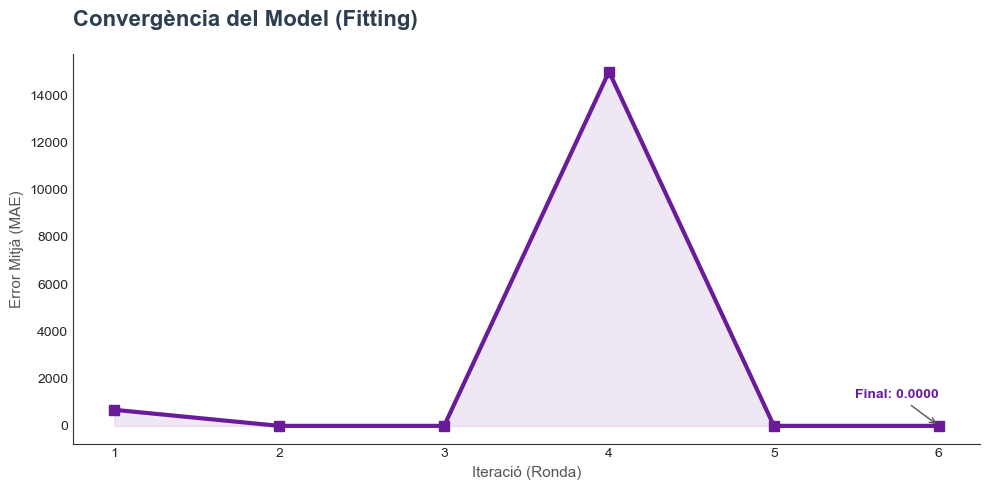

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- CÀRREGA DE DADES ---
folder_path = r"C:\Users\Usuario\Desktop\Himmelblau"
input_consolidat = os.path.join(folder_path, "Taula_Resum_Global_Himmelblau.csv")

if os.path.exists(input_consolidat):
    df = pd.read_csv(input_consolidat)
    df['Num_Ronda'] = df['RONDES'].str.replace('R', '').astype(int)
    df = df.sort_values('Num_Ronda')

    # --- CONFIGURACIÓ ESTÈTICA GENERAL ---
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.edgecolor'] = '#333333'
    plt.rcParams['axes.linewidth'] = 0.8
    
    # Colors moderns (Paleta tipus "Tableau" o "Flat UI")
    colors_sampling = ['#219ebc', '#023047', '#ffb703', '#fb8500'] 
    color_fitting = '#6a1b9a' # Un lila intens i elegant

    # =========================================================
    # --- GRÀFIC 1: SAMPLING (MINIMALISTA) ---
    # =========================================================
    fig, ax1 = plt.subplots(figsize=(10, 6))

    columnes_dist = ['Distància M1', 'Distància M2', 'Distància M3', 'Distància M4']
    labels_dist = ['Mínim 1', 'Mínim 2', 'Mínim 3', 'Mínim 4']

    for i, columna in enumerate(columnes_dist):
        ax1.plot(df['Num_Ronda'], df[columna], 
                 marker='o', markersize=8, markerfacecolor='white', markeredgewidth=2,
                 linestyle='-', linewidth=3, color=colors_sampling[i], 
                 label=labels_dist[i], alpha=0.9)

    # Personalització d'eixos
    ax1.set_title('Exploració de l\'Espai (Sampling)', loc='left', fontsize=16, fontweight='bold', pad=20, color='#2c3e50')
    ax1.set_xlabel('Iteració (Ronda)', fontsize=11, color='#555555')
    ax1.set_ylabel('Distància al Mínim', fontsize=11, color='#555555')
    
    # Traure quadrícules i línies de dalt i la dreta
    ax1.grid(False) # Fora línies de fons
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # Només mostrar els números de ronda que existeixen
    ax1.set_xticks(df['Num_Ronda'])
    
    # Llegenda sense marc i ben situada
    ax1.legend(frameon=False, fontsize=10, loc='upper right')

    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, "Sampling_Clean.png"), dpi=300, transparent=True)
    plt.show()

    # =========================================================
    # --- GRÀFIC 2: FITTING (MAE - ESTIL NET) ---
    # =========================================================
    fig, ax2 = plt.subplots(figsize=(10, 5))

    # Àrea omplerta per sota de la línia per donar un toc modern
    ax2.fill_between(df['Num_Ronda'], df['MAE'], color=color_fitting, alpha=0.1)
    ax2.plot(df['Num_Ronda'], df['MAE'], 
             marker='s', markersize=7, color=color_fitting, 
             linewidth=3, label='MAE')

    ax2.set_title('Convergència del Model (Fitting)', loc='left', fontsize=16, fontweight='bold', pad=20, color='#2c3e50')
    ax2.set_xlabel('Iteració (Ronda)', fontsize=11, color='#555555')
    ax2.set_ylabel('Error Mitjà (MAE)', fontsize=11, color='#555555')

    # Estètica minimalista
    ax2.grid(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_xticks(df['Num_Ronda'])

    # Afegir anotació al punt final si és molt baix
    final_mae = df['MAE'].iloc[-1]
    ax2.annotate(f'Final: {final_mae:.4f}', 
                 xy=(df['Num_Ronda'].iloc[-1], final_mae),
                 xytext=(-60, 20), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='#555555'),
                 fontsize=10, fontweight='bold', color=color_fitting)

    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, "Fitting_Clean.png"), dpi=300, transparent=True)
    plt.show()

else:
    print("No s'ha trobat el fitxer consolidat.")